<a href="https://colab.research.google.com/github/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics/blob/main/AI_Powered_Soil_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -o archive.zip

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.


##**MILESTONE 1**

In [4]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics/main/data/raw/crop_fertilizer_recommendation_dataset.csv"
)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer,N_status,P_status,K_status,recommendation_note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,DAP (Diammonium Phosphate),Normal,Low,Normal,Based on NPK + climate conditions
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2200
Number of columns: 13


In [6]:
print(df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'fertilizer', 'N_status', 'P_status', 'K_status', 'recommendation_note']


In [7]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0
fertilizer,0
N_status,0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object
fertilizer,object
N_status,object


In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
print("Number of crop classes:", df["label"].nunique())
print("\nCrop distribution:")
print(df["label"].value_counts())

Number of crop classes: 22

Crop distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [12]:
print("Number of fertilizer categories:", df["fertilizer"].nunique())
print("\nFertilizer distribution:")
print(df["fertilizer"].value_counts())

Number of fertilizer categories: 5

Fertilizer distribution:
fertilizer
Urea (Nitrogen rich fertilizer)    914
Balanced NPK (10-26-26)            378
DAP (Diammonium Phosphate)         371
MOP (Muriate of Potash)            274
Balanced NPK (14-14-14)            263
Name: count, dtype: int64


In [13]:
print(df["recommendation_note"].value_counts())


recommendation_note
Based on NPK + climate conditions    2200
Name: count, dtype: int64


In [14]:
print("Nitrogen Status:")
print(df["N_status"].value_counts())

print("\nPhosphorus Status:")
print(df["P_status"].value_counts())

print("\nPotassium Status:")
print(df["K_status"].value_counts())


Nitrogen Status:
N_status
Low       1292
Normal     614
High       294
Name: count, dtype: int64

Phosphorus Status:
P_status
Normal    1192
Low        808
High       200
Name: count, dtype: int64

Potassium Status:
K_status
Low       1335
Normal     665
High       200
Name: count, dtype: int64


In [15]:
print("Negative N values:", (df["N"] < 0).sum())
print("Negative P values:", (df["P"] < 0).sum())
print("Negative K values:", (df["K"] < 0).sum())
print("Invalid pH values:", ((df["ph"] < 0) | (df["ph"] > 14)).sum())
print("Invalid humidity values:", ((df["humidity"] < 0) | (df["humidity"] > 100)).sum())

Negative N values: 0
Negative P values: 0
Negative K values: 0
Invalid pH values: 0
Invalid humidity values: 0


In [16]:
numeric_columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower) | (df[column] > upper)).sum()

    print(column, ":", outliers, "outliers")


N : 0 outliers
P : 138 outliers
K : 200 outliers
temperature : 86 outliers
humidity : 30 outliers
ph : 57 outliers
rainfall : 100 outliers


In [17]:
df.groupby("label")[["N", "P", "K", "ph"]].mean().round(2)

,N,P,K,ph
label,,,,
apple,20.80,134.22,199.89,5.93
banana,100.23,82.01,50.05,5.98
blackgram,40.02,67.47,19.24,7.13
chickpea,40.09,67.79,79.92,7.34
coconut,21.98,16.93,30.59,5.98
coffee,101.20,28.74,29.94,6.79
cotton,117.77,46.24,19.56,6.91
grapes,23.18,132.53,200.11,6.03
jute,78.40,46.86,39.99,6.73


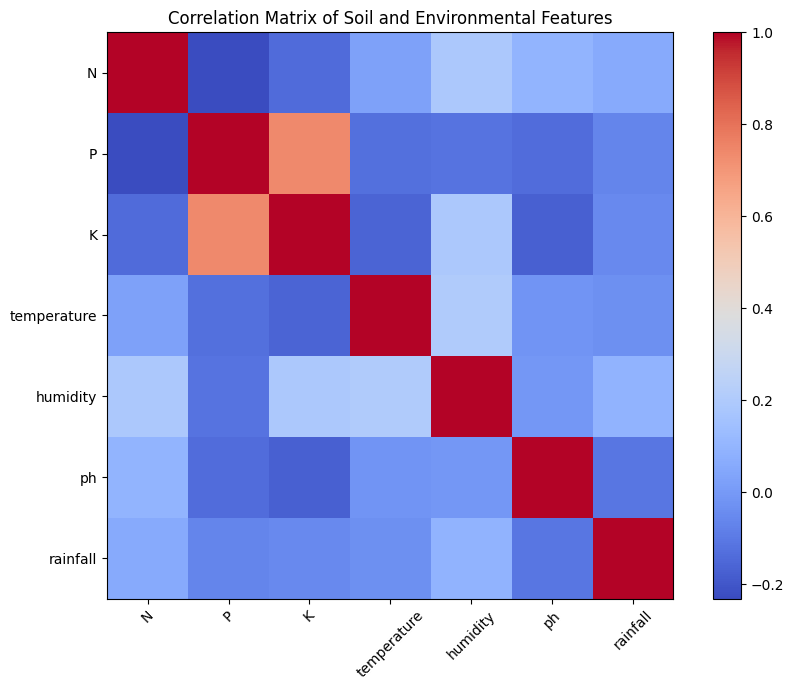

In [18]:
import matplotlib.pyplot as plt

corr = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Soil and Environmental Features")
plt.tight_layout()
plt.show()

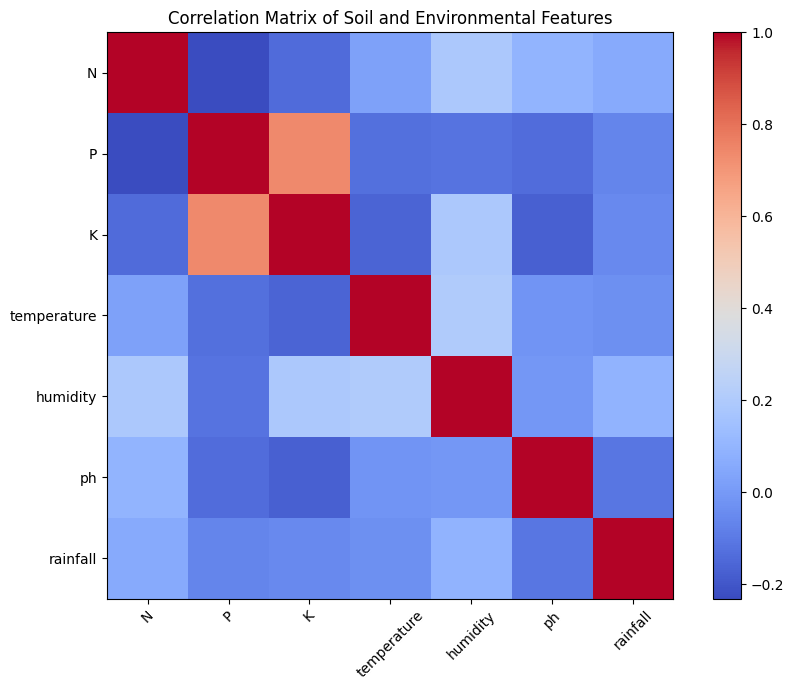

In [29]:
import matplotlib.pyplot as plt

corr = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Soil and Environmental Features")
plt.tight_layout()
plt.show()

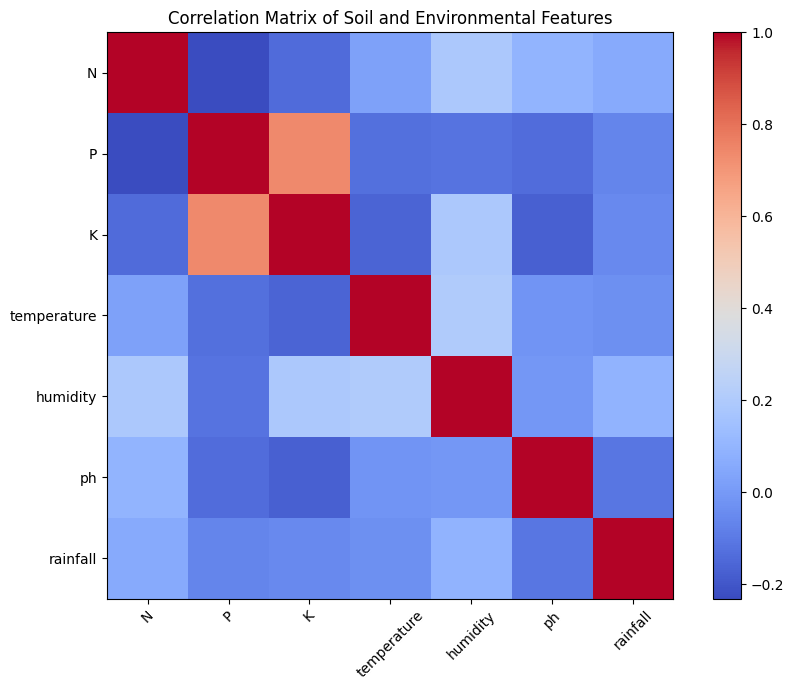

In [22]:
import matplotlib.pyplot as plt

corr = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix of Soil and Environmental Features")
plt.tight_layout()
plt.show()

In [23]:
pd.crosstab(df["label"], df["fertilizer"])


fertilizer,Balanced NPK (10-26-26),Balanced NPK (14-14-14),DAP (Diammonium Phosphate),MOP (Muriate of Potash),Urea (Nitrogen rich fertilizer)
label,,,,,
apple,0,0,0,0,100
banana,0,100,0,0,0
blackgram,0,0,0,31,69
chickpea,0,28,0,0,72
coconut,100,0,0,0,0
coffee,0,0,91,9,0
cotton,0,0,24,76,0
grapes,0,0,0,0,100
jute,0,45,16,39,0


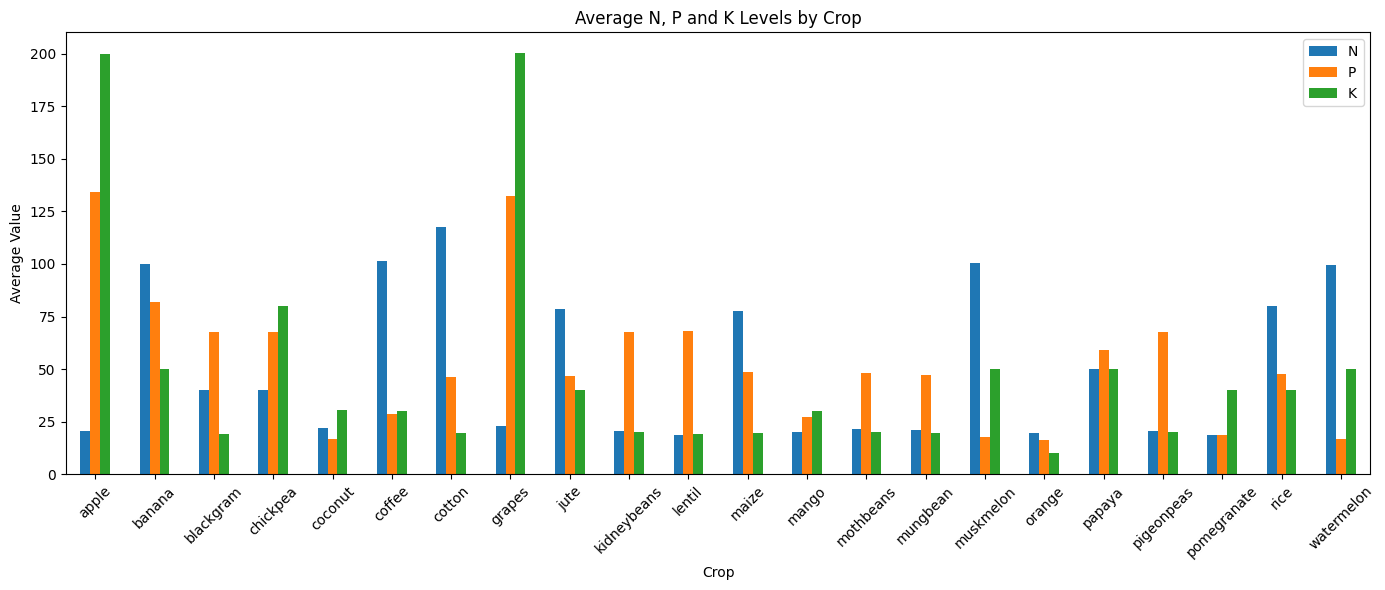

In [24]:
df.groupby("label")[["N", "P", "K"]].mean().plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Average N, P and K Levels by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

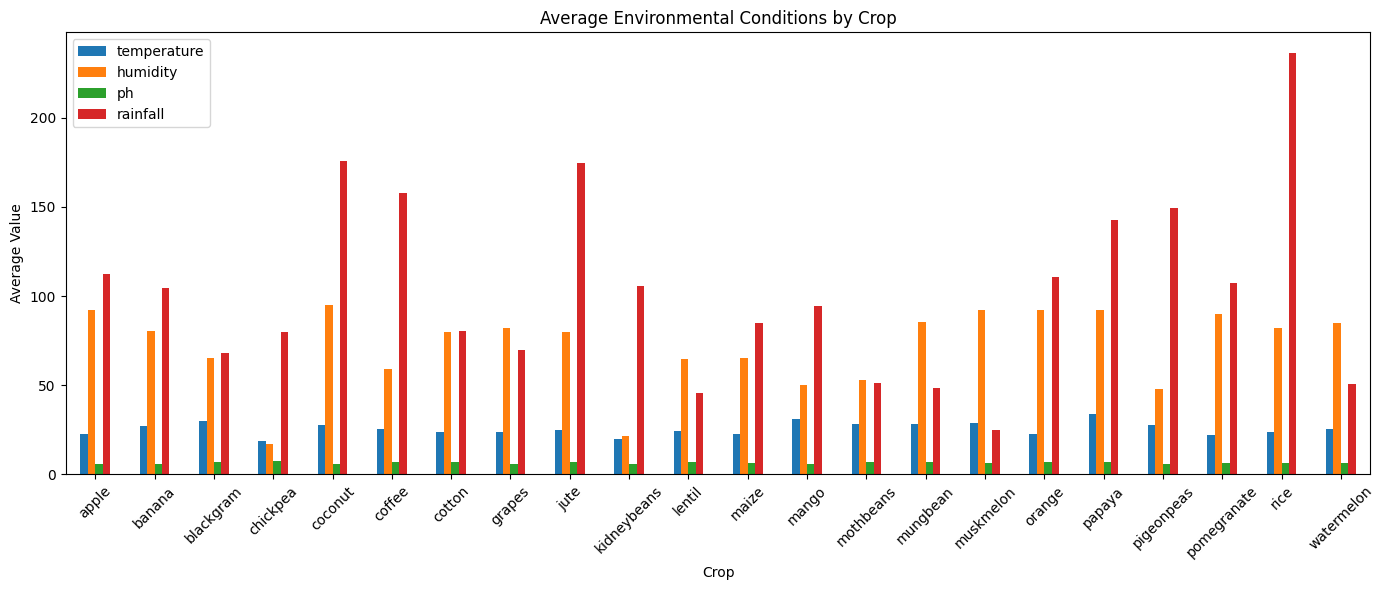

In [25]:
df.groupby("label")[["temperature", "humidity", "ph", "rainfall"]].mean().plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Average Environmental Conditions by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
print("N Status:")
print(df["N_status"].value_counts())

print("\nP Status:")
print(df["P_status"].value_counts())

print("\nK Status:")
print(df["K_status"].value_counts())

N Status:
N_status
Low       1292
Normal     614
High       294
Name: count, dtype: int64

P Status:
P_status
Normal    1192
Low        808
High       200
Name: count, dtype: int64

K Status:
K_status
Low       1335
Normal     665
High       200
Name: count, dtype: int64


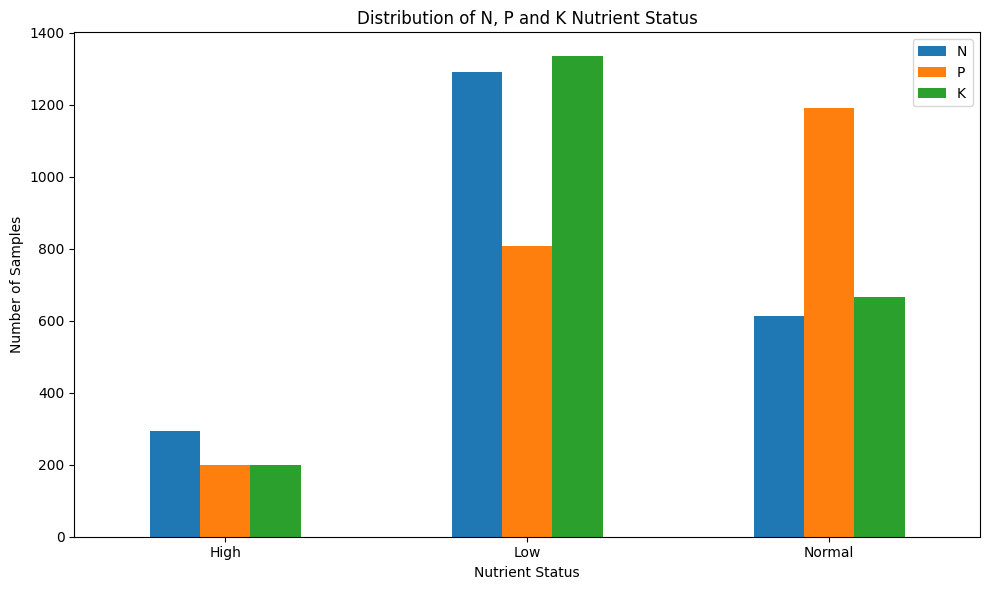

In [27]:
status_data = pd.DataFrame({
    "N": df["N_status"].value_counts(),
    "P": df["P_status"].value_counts(),
    "K": df["K_status"].value_counts()
}).fillna(0)

status_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribution of N, P and K Nutrient Status")
plt.xlabel("Nutrient Status")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## **MIlSTONE 2**

In [30]:
import os

dataset_path = "images/Original-Dataset"

classes = sorted(os.listdir(dataset_path))

print("Number of Classes:", len(classes))
print("\nClasses:")
for cls in classes:
    print("-", cls)

FileNotFoundError: [Errno 2] No such file or directory: 'images/Original-Dataset'

In [31]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current directory:
/content

Files and folders:
['.config', 'sample_data']


In [32]:
!git clone https://github.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics

Cloning into 'AI-Powered-Soil-Analytics'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 21 (delta 6), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 291.76 KiB | 1.97 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [33]:
import os

print(os.listdir("/content"))

['.config', 'AI-Powered-Soil-Analytics', 'sample_data']


In [34]:
import os

project_path = "/content/AI-Powered-Soil-Analytics"

print(os.listdir(project_path))

['dataset_inventory.txt', '.gitattributes', '.git', 'data', 'AI_Powered_Soil_Analytics.ipynb', 'requirements.txt', '.gitignore']


In [35]:
import os

data_path = "/content/AI-Powered-Soil-Analytics/data"

print(os.listdir(data_path))

['raw']


In [36]:
import os

raw_path = "/content/AI-Powered-Soil-Analytics/data/raw"

print(os.listdir(raw_path))

['crop_fertilizer_recommendation_dataset.csv']


In [37]:
inventory_path = "/content/AI-Powered-Soil-Analytics/dataset_inventory.txt"

with open(inventory_path, "r") as f:
    print(f.read())

AI-POWERED SOIL ANALYTICS FOR CROP MANAGEMENT
Dataset Inventory

1. Structured Dataset
Dataset Name: Crop and Fertilizer Recommendation Dataset
Source: Kaggle
Records: 2,200
Columns: 13
Format: CSV
License: CC0 – Public Domain

Main Features:
- Nitrogen (N)
- Phosphorus (P)
- Potassium (K)
- Temperature
- Humidity
- pH
- Rainfall

Target/Recommendation Information:
- Crop label
- Fertilizer
- N status
- P status
- K status
- Recommendation note

Number of Crop Classes: 22
Number of Fertilizer Categories: 5

Initial Data Checks:
- Missing values: 0
- Duplicate records: 0
- Invalid basic numerical values: 0

2. Soil Image Dataset
Dataset Name: Soil Classification Dataset
Source: GitHub
Format: JPG/PNG images
Number of Soil Classes: 7
License: CC BY-NC 4.0

Soil Classes:
- Alluvial Soil: 52 images
- Arid Soil: 284 images
- Black Soil: 255 images
- Laterite Soil: 219 images
- Mountain Soil: 201 images
- Red Soil: 109 images
- Yellow Soil: 69 images

Purpose:
The image dataset will be used 

In [38]:
!cd /content/AI-Powered-Soil-Analytics && git branch -a

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/main


In [39]:
!cd /content/AI-Powered-Soil-Analytics && git ls-tree -r --name-only HEAD | head -100

.gitattributes
.gitignore
AI_Powered_Soil_Analytics.ipynb
data/raw/crop_fertilizer_recommendation_dataset.csv
dataset_inventory.txt
requirements.txt


In [40]:
!grep -Rni "Soil Classification Dataset\|github.com" /content/AI-Powered-Soil-Analytics

/content/AI-Powered-Soil-Analytics/dataset_inventory.txt:38:Dataset Name: Soil Classification Dataset
/content/AI-Powered-Soil-Analytics/.git/config:7:	url = https://github.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics
/content/AI-Powered-Soil-Analytics/.git/logs/refs/heads/main:1:0000000000000000000000000000000000000000 63706fc5ccc367fdb2570205ceefd9a9d229f0c4 root <root@86c8c2a29586.(none)> 1788768621 +0000	clone: from https://github.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics
/content/AI-Powered-Soil-Analytics/.git/logs/refs/remotes/origin/HEAD:1:0000000000000000000000000000000000000000 63706fc5ccc367fdb2570205ceefd9a9d229f0c4 root <root@86c8c2a29586.(none)> 1788768621 +0000	clone: from https://github.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics
/content/AI-Powered-Soil-Analytics/.git/logs/HEAD:1:0000000000000000000000000000000000000000 63706fc5ccc367fdb2570205ceefd9a9d229f0c4 root <root@86c8c2a29586.(none)> 1788768621 +0000	clone: from https://github.com/jyo

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import os

print(os.listdir("/content/drive/MyDrive"))

['resume (3).pdf', 'resume (2).pdf', 'resume (1).pdf', 'Your big idea.gslides', 'How Computers Reshaped Our Daily Lives (1).gslides', 'How Computers Reshaped Our Daily Lives.pptx', 'How Computers Reshaped Our Daily Lives.gslides', 'IMG-20250810-WA0033.jpg', 'Resume (7).gdoc', 'Resume (6).gdoc', 'Resume (5).gdoc', 'Resume (4).gdoc', 'Resume (3).gdoc', 'Resume.pdf', 'Colab Notebooks', 'Screenshot_2025-10-09-17-41-10-18_944a2809ea1b4cda6ef12d1db9048ed3.jpg', 'My Book.gdoc', 'resume.pdf', 'Resume (2).gdoc', 'Resume (1).gdoc', 'Copy of Resume.gdoc', 'Bankuru Jyothsna resume (7).pdf', 'Bankuru Jyothsna resume (6).pdf', 'Bankuru Jyothsna resume (5).pdf', 'Bankuru Jyothsna resume (4).pdf', 'Bankuru Jyothsna resume (3).pdf', 'Bankuru Jyothsna resume (2).pdf', 'Bankuru Jyothsna resume (1).pdf', 'Bankuru Jyothsna resume.pdf', 'Resume.gdoc', 'Credentials - jyothsnabankuru-8688 | Microsoft Learn.pdf', 'tencon ST internship.jpg', 'AICTE IBM SkillsBuild Academic Internship - Data Analytics with AI Bh

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from google.colab import files

uploaded = files.upload()